# NEXRAD radar — catalog explorer (no network)

Explore the bundled WSR-88D station registry offline: counts, a lookup, a bounding-box query, and a scatter of every site. No S3 access — this notebook runs deterministically at docs-build time.

In [1]:
from earthlens.radar import StationCatalog

cat = StationCatalog()
print(f'catalogued WSR-88D sites: {len(cat.datasets)}')

catalogued WSR-88D sites: 210


In [2]:
ktlx = cat.get_station('KTLX')
print(ktlx.name, ktlx.state, ktlx.latitude, ktlx.longitude)

Oklahoma City OK 35.3334 -97.2778


In [3]:
cat.in_bbox(-100, 33, -95, 37)

['KCRI', 'KFDR', 'KINX', 'KOUN', 'KTLX', 'KVNX', 'TDFW', 'TOKC', 'TTUL']

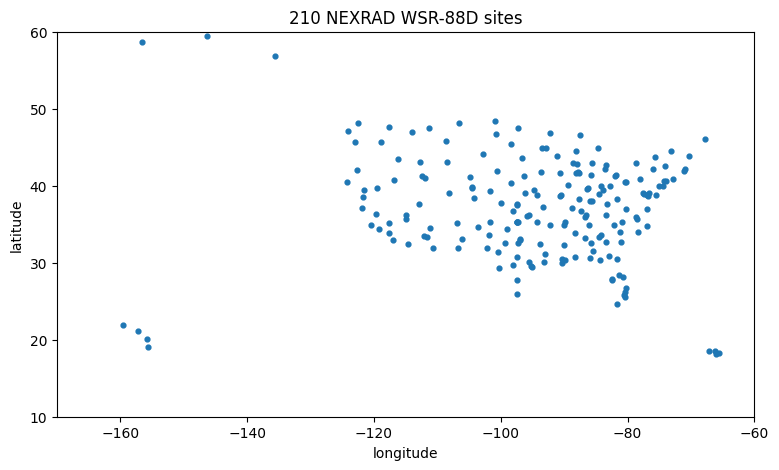

In [4]:
import matplotlib.pyplot as plt

lons = [s.longitude for s in cat.datasets.values()]
lats = [s.latitude for s in cat.datasets.values()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(lons, lats, s=12, c='tab:blue')
ax.set(xlabel='longitude', ylabel='latitude',
       title=f'{len(lats)} NEXRAD WSR-88D sites')
ax.set_xlim(-170, -60)
ax.set_ylim(10, 60)
plt.show()